Loading 20 Newsgroups for EDA...
Categories: 20
Train docs: 11314
Test docs:  7532


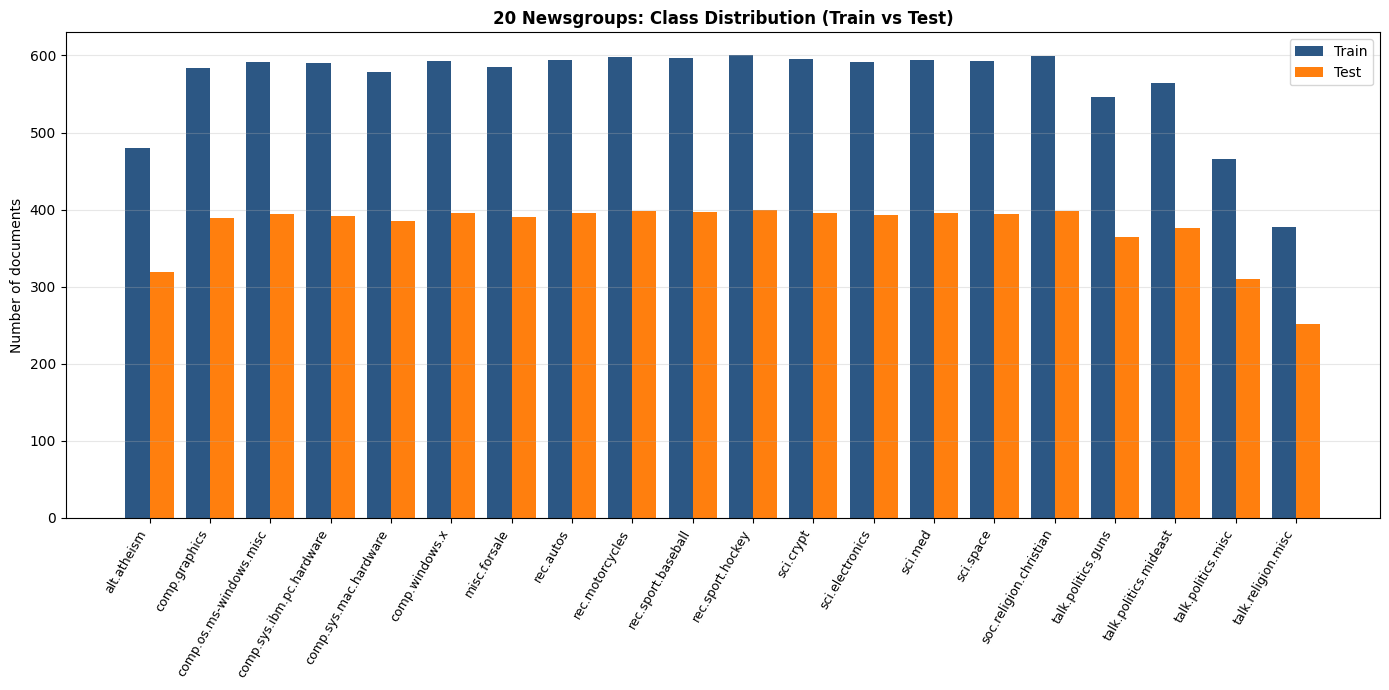

✅ Saved: eda_class_distribution.png


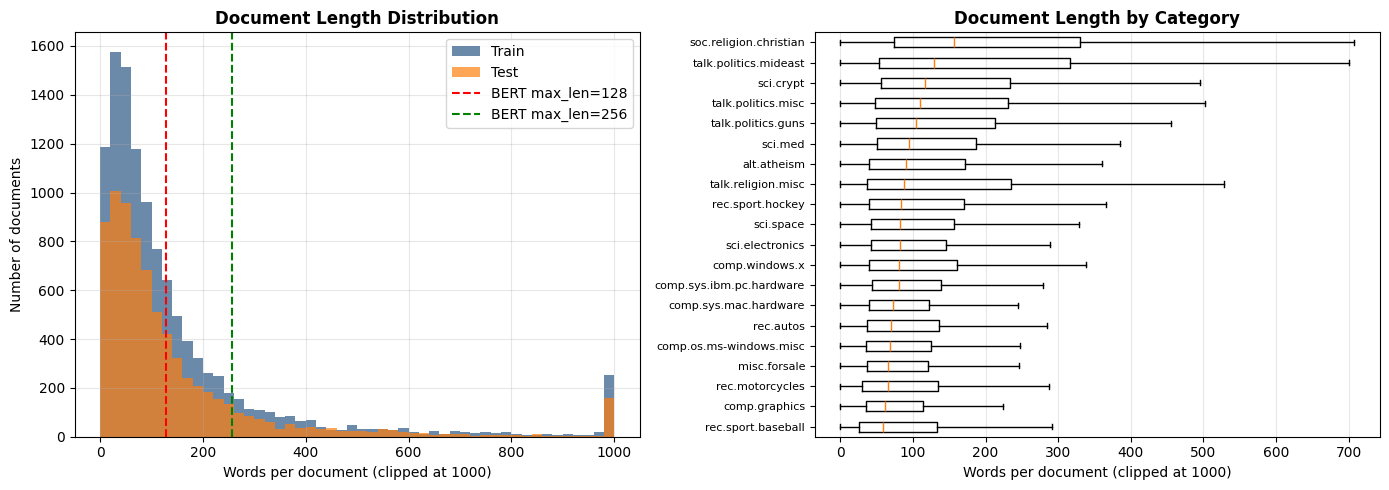

✅ Saved: eda_doc_length.png

Document length statistics:
  Mean:   186 words
  Median: 83 words
  90th %: 336 words
  Max:    11765 words
  >128 tokens:  33.8% of docs
  >256 tokens:  14.3% of docs


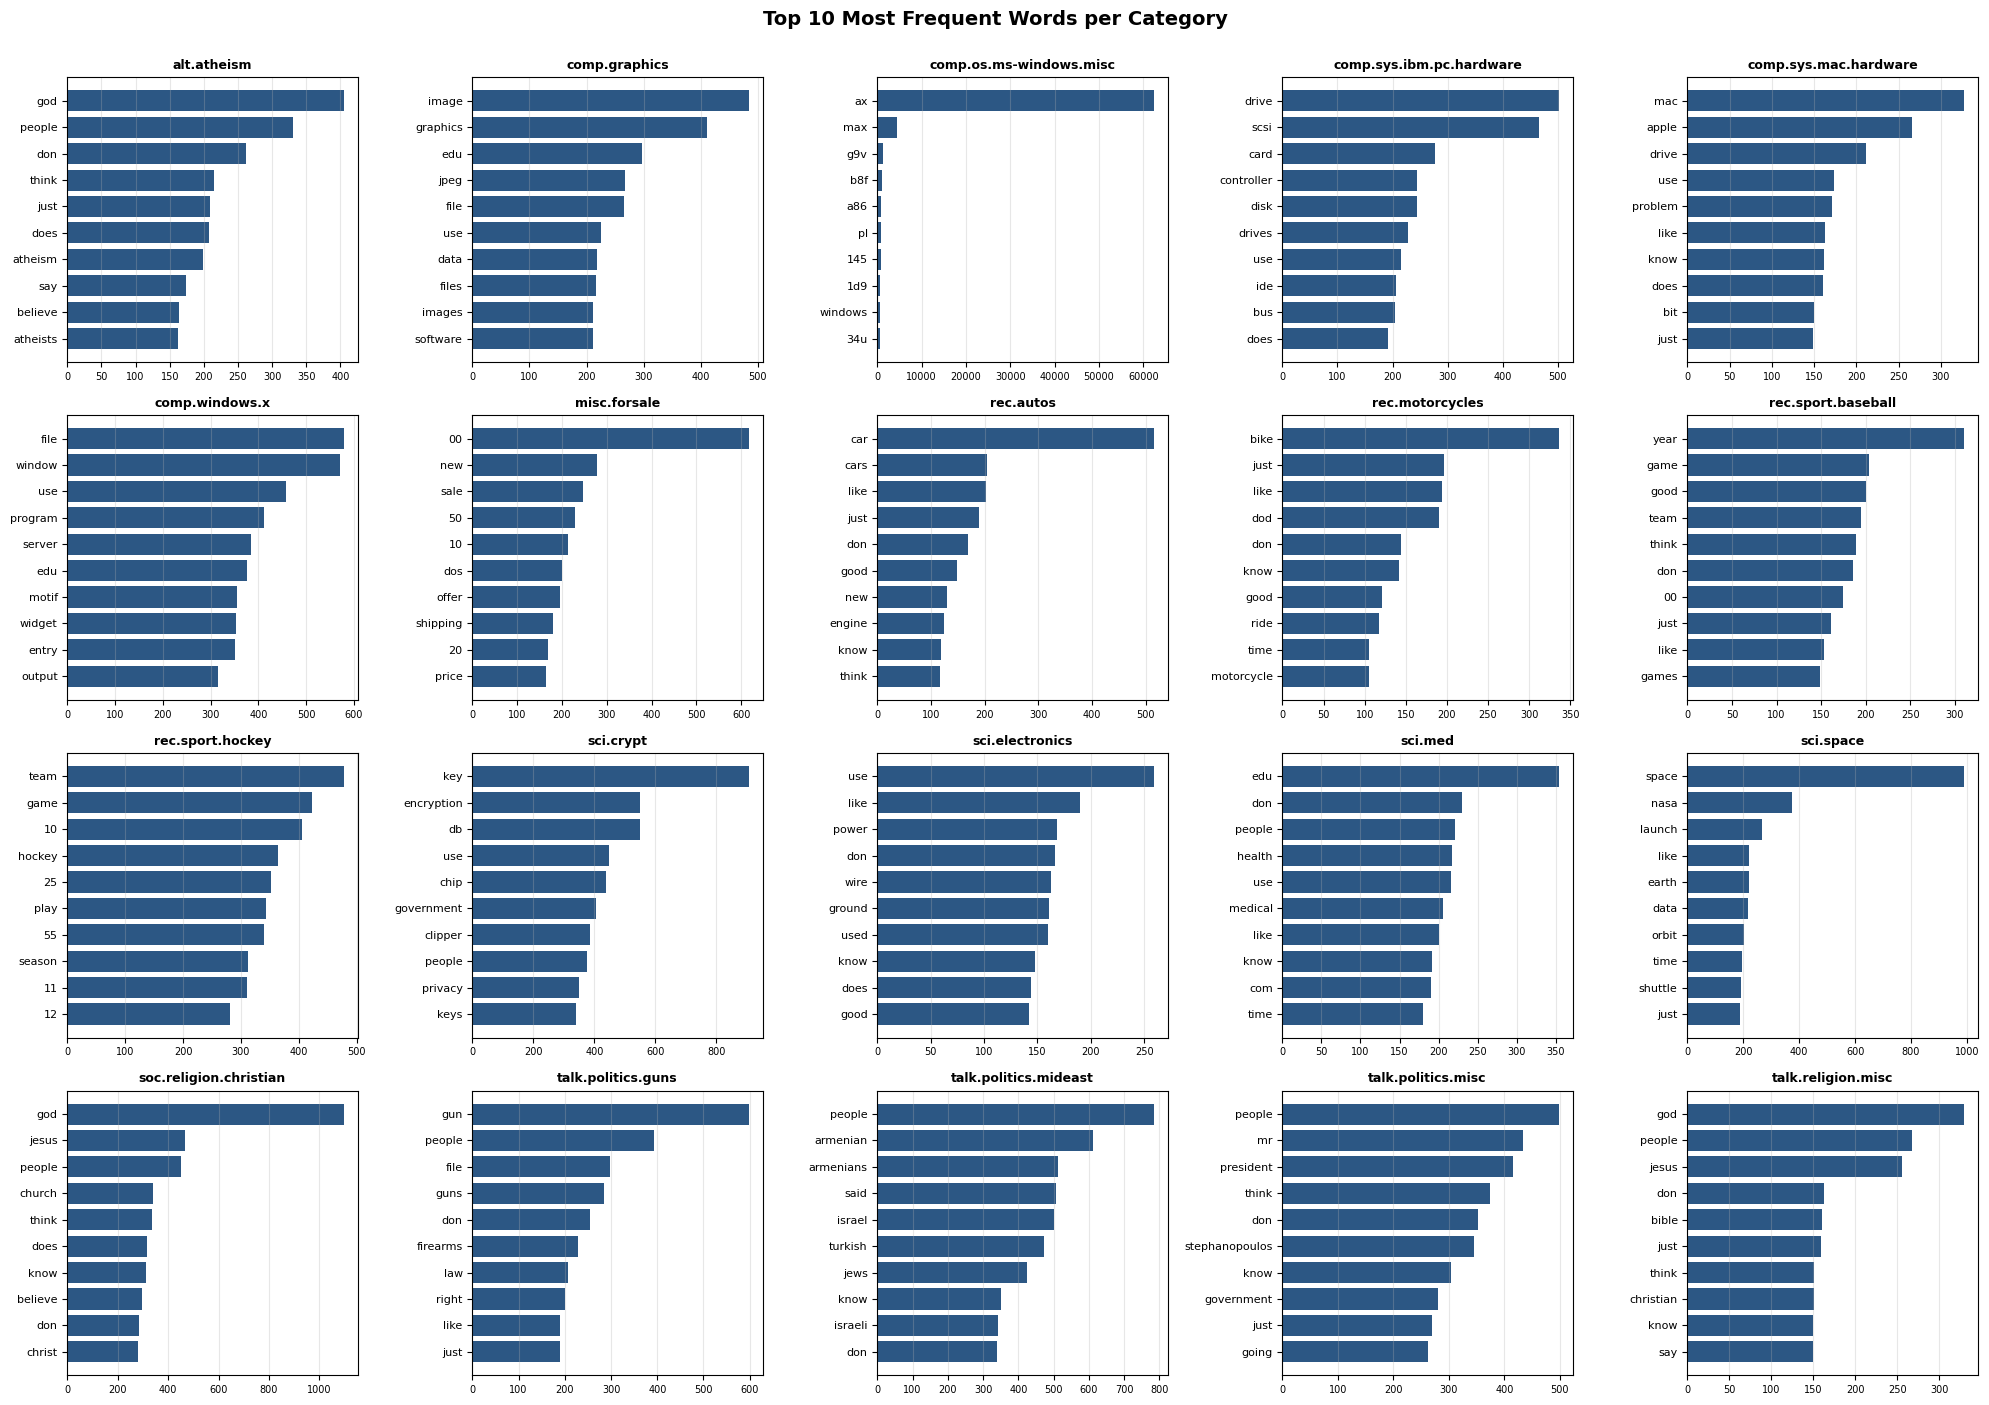

✅ Saved: eda_top_words_per_class.png

Vocabulary statistics (train set):
  Total tokens:     1,624,113
  Unique tokens:    46,733
  Tokens / doc avg: 144
  Hapax (1-count):  19,710 (42.2% of vocab)


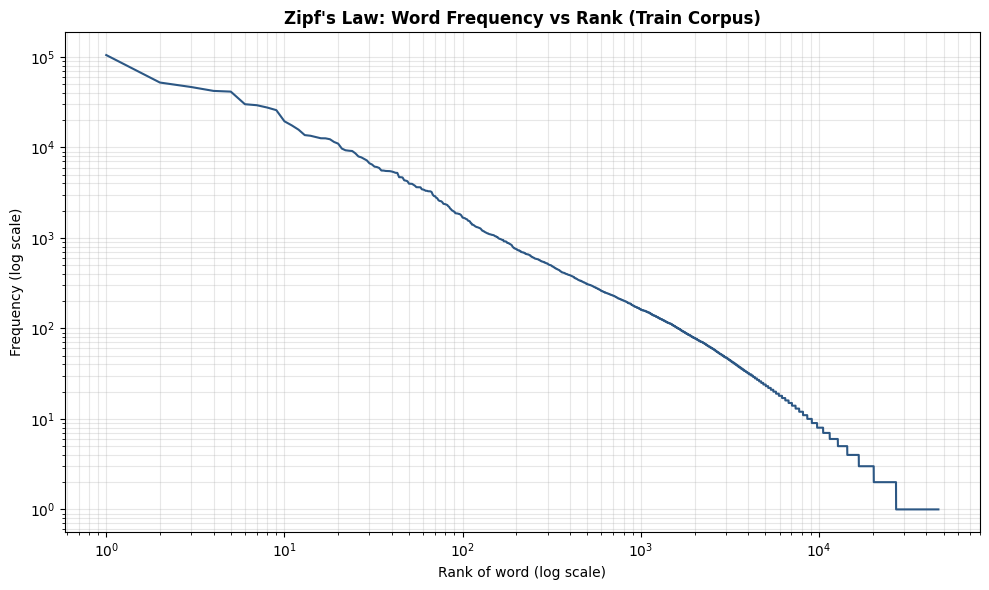

✅ Saved: eda_zipf.png


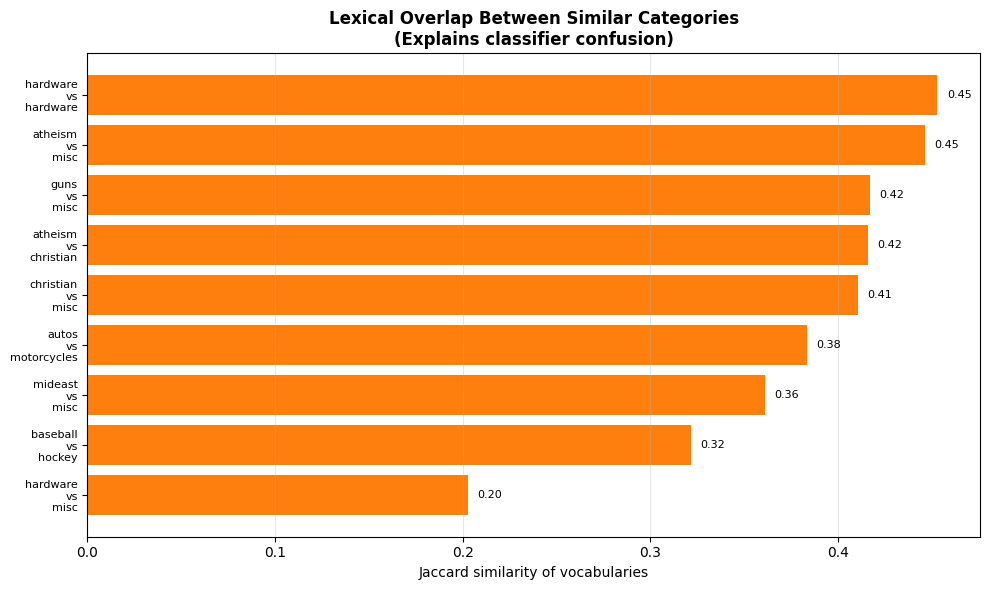

✅ Saved: eda_category_overlap.png

EDA COMPLETE — all plots saved to outputs/plots/


In [16]:
#EDA

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

os.makedirs('outputs/plots', exist_ok=True)

print("Loading 20 Newsgroups for EDA...")
train_raw = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_raw  = fetch_20newsgroups(subset='test',  remove=('headers', 'footers', 'quotes'))

CATEGORIES = train_raw.target_names
print(f"Categories: {len(CATEGORIES)}")
print(f"Train docs: {len(train_raw.data)}")
print(f"Test docs:  {len(test_raw.data)}")

# PLOT 1: Class distribution
train_counts = Counter(train_raw.target)
test_counts  = Counter(test_raw.target)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(CATEGORIES))
width = 0.4
ax.bar(x - width/2, [train_counts[i] for i in range(20)], width, label='Train', color='#2c5784')
ax.bar(x + width/2, [test_counts[i]  for i in range(20)], width, label='Test',  color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES, rotation=60, ha='right', fontsize=9)
ax.set_ylabel('Number of documents')
ax.set_title('20 Newsgroups: Class Distribution (Train vs Test)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/plots/eda_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_class_distribution.png")

# PLOT 2: Document length distribution
train_lengths = [len(doc.split()) for doc in train_raw.data]
test_lengths  = [len(doc.split()) for doc in test_raw.data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (capped at 1000 words for readability)
axes[0].hist(np.clip(train_lengths, 0, 1000), bins=50, alpha=0.7, label='Train', color='#2c5784')
axes[0].hist(np.clip(test_lengths,  0, 1000), bins=50, alpha=0.7, label='Test',  color='#ff7f0e')
axes[0].axvline(128, color='red',   linestyle='--', label='BERT max_len=128')
axes[0].axvline(256, color='green', linestyle='--', label='BERT max_len=256')
axes[0].set_xlabel('Words per document (clipped at 1000)')
axes[0].set_ylabel('Number of documents')
axes[0].set_title('Document Length Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot per category
length_by_cat = {CATEGORIES[i]: [] for i in range(20)}
for length, cat in zip(train_lengths, train_raw.target):
    length_by_cat[CATEGORIES[cat]].append(min(length, 1000))

# Sort by median length
sorted_cats = sorted(length_by_cat.keys(), key=lambda k: np.median(length_by_cat[k]))
axes[1].boxplot([length_by_cat[c] for c in sorted_cats], vert=False, showfliers=False)
axes[1].set_yticklabels(sorted_cats, fontsize=8)
axes[1].set_xlabel('Words per document (clipped at 1000)')
axes[1].set_title('Document Length by Category', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/plots/eda_doc_length.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_doc_length.png")

print(f"\nDocument length statistics:")
print(f"  Mean:   {np.mean(train_lengths):.0f} words")
print(f"  Median: {np.median(train_lengths):.0f} words")
print(f"  90th %: {np.percentile(train_lengths, 90):.0f} words")
print(f"  Max:    {np.max(train_lengths)} words")
print(f"  >128 tokens:  {sum(1 for x in train_lengths if x > 128) / len(train_lengths) * 100:.1f}% of docs")
print(f"  >256 tokens:  {sum(1 for x in train_lengths if x > 256) / len(train_lengths) * 100:.1f}% of docs")

# PLOT 3: Top words per category
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

vectorizer = CountVectorizer(stop_words='english', max_features=20000,
                              lowercase=True, min_df=2)
X_counts = vectorizer.fit_transform(train_raw.data)
vocab = vectorizer.get_feature_names_out()

for i, cat in enumerate(CATEGORIES):
    cat_mask = np.array(train_raw.target) == i
    cat_word_counts = np.asarray(X_counts[cat_mask].sum(axis=0)).flatten()
    top_indices = cat_word_counts.argsort()[-10:][::-1]
    top_words = [vocab[j] for j in top_indices]
    top_counts = [cat_word_counts[j] for j in top_indices]

    axes[i].barh(range(10), top_counts[::-1], color='#2c5784')
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(top_words[::-1], fontsize=8)
    axes[i].set_title(cat, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('Top 10 Most Frequent Words per Category', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('outputs/plots/eda_top_words_per_class.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_top_words_per_class.png")

# PLOT 4: Vocabulary statistics
total_words = sum(train_lengths)
all_tokens = [token.lower() for doc in train_raw.data for token in doc.split() if token.isalpha()]
unique_tokens = set(all_tokens)
token_counts = Counter(all_tokens)
hapax = sum(1 for w, c in token_counts.items() if c == 1)

print(f"\nVocabulary statistics (train set):")
print(f"  Total tokens:     {len(all_tokens):,}")
print(f"  Unique tokens:    {len(unique_tokens):,}")
print(f"  Tokens / doc avg: {len(all_tokens) / len(train_raw.data):.0f}")
print(f"  Hapax (1-count):  {hapax:,} ({hapax/len(unique_tokens)*100:.1f}% of vocab)")

# Zipf plot
sorted_counts = sorted(token_counts.values(), reverse=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(range(1, len(sorted_counts)+1), sorted_counts, color='#2c5784')
ax.set_xlabel('Rank of word (log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title("Zipf's Law: Word Frequency vs Rank (Train Corpus)", fontweight='bold')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('outputs/plots/eda_zipf.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_zipf.png")

# PLOT 5: Confusion of similar categories (semantic overlap analysis)
# Pick category pairs that are thematically similar
similar_pairs = [
    ('alt.atheism', 'soc.religion.christian'),
    ('alt.atheism', 'talk.religion.misc'),
    ('soc.religion.christian', 'talk.religion.misc'),
    ('comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware'),
    ('comp.sys.ibm.pc.hardware', 'comp.os.ms-windows.misc'),
    ('rec.autos', 'rec.motorcycles'),
    ('rec.sport.baseball', 'rec.sport.hockey'),
    ('talk.politics.guns', 'talk.politics.misc'),
    ('talk.politics.mideast', 'talk.politics.misc'),
]

def category_vocab(category):
    """Get word counts for a category."""
    idx = CATEGORIES.index(category)
    mask = np.array(train_raw.target) == idx
    counts = np.asarray(X_counts[mask].sum(axis=0)).flatten()
    return set(vocab[counts > 5])  # words appearing 5+ times

overlap_data = []
for cat1, cat2 in similar_pairs:
    v1 = category_vocab(cat1)
    v2 = category_vocab(cat2)
    jaccard = len(v1 & v2) / len(v1 | v2)
    overlap_data.append({
        'pair': f"{cat1.split('.')[-1]}\nvs\n{cat2.split('.')[-1]}",
        'jaccard': jaccard,
        'shared_words': len(v1 & v2),
    })

df = pd.DataFrame(overlap_data).sort_values('jaccard', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(df)), df['jaccard'], color='#ff7f0e')
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['pair'], fontsize=8)
ax.set_xlabel('Jaccard similarity of vocabularies')
ax.set_title('Lexical Overlap Between Similar Categories\n(Explains classifier confusion)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, (bar, jc) in enumerate(zip(bars, df['jaccard'])):
    ax.text(jc + 0.005, i, f"{jc:.2f}", va='center', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/plots/eda_category_overlap.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_category_overlap.png")

print("\n" + "="*60)
print("EDA COMPLETE — all plots saved to outputs/plots/")
print("="*60)

In [1]:
import os
import zipfile

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

zip_path = "/content/nalapro-project-final.zip"
extract_to = "/content/"

print("\nUnzipping...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

%cd /content/nalapro-project-final

print("\nDirectory contents:")
!ls -la

CUDA available: True
GPU: Tesla T4
VRAM: 15.637086208 GB

Unzipping...
/content/nalapro-project-final

Directory contents:
total 60
drwxr-xr-x 10 root root 4096 May 20 15:12 .
drwxr-xr-x  1 root root 4096 May 20 15:12 ..
-rw-r--r--  1 root root 2818 May 20 15:12 config.py
drwxr-xr-x  2 root root 4096 May 20 15:12 docs
-rw-r--r--  1 root root  363 May 20 15:12 .gitignore
drwxr-xr-x  2 root root 4096 May 20 15:12 .ipynb_checkpoints
drwxr-xr-x  2 root root 4096 May 20 15:12 notebooks
drwxr-xr-x  4 root root 4096 May 20 15:12 outputs
drwxr-xr-x  2 root root 4096 May 20 15:12 __pycache__
-rw-r--r--  1 root root 3808 May 20 15:12 README.md
drwxr-xr-x  2 root root 4096 May 20 15:12 report
-rw-r--r--  1 root root  503 May 20 15:12 requirements.txt
-rw-r--r--  1 root root 2056 May 20 15:12 run_all.py
drwxr-xr-x  8 root root 4096 May 20 15:12 src
drwxr-xr-x  9 root root 4096 May 20 15:12 wandb


In [2]:
!pip install -q -r requirements.txt
!pip install -q bitsandbytes>=0.43.0 accelerate>=0.30.0
print("\n✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.3 MB/s eta 0:00:00

✅ Dependencies installed


In [3]:
import os
os.environ["WANDB_API_KEY"] = "hehe"

import wandb
wandb.login()
print("\n✅ W&B logged in")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: nilabhpandey7 (nilabhpandey7-hslu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



✅ W&B logged in


In [4]:
from huggingface_hub import login
login(token="haha", add_to_git_credential=False)
print("\n✅ Hugging Face logged in")


✅ Hugging Face logged in


In [5]:
import re

with open('config.py', 'r') as f:
    content = f.read()

content = re.sub(r'BERT_BATCH_SIZE = \d+', 'BERT_BATCH_SIZE = 16', content)
content = re.sub(r'BERT_EPOCHS = \d+', 'BERT_EPOCHS = 3', content)
content = re.sub(r'BERT_MAX_LEN = \d+', 'BERT_MAX_LEN = 128', content)
content = re.sub(r'MLM_EPOCHS = \d+', 'MLM_EPOCHS = 2', content)
content = re.sub(r'MLM_BATCH_SIZE = \d+', 'MLM_BATCH_SIZE = 16', content)

with open('config.py', 'w') as f:
    f.write(content)

print("Updated config values:")
!grep -E "BERT_|MLM_" config.py
print("\n✅ Config updated for GPU")

Updated config values:
BERT_MODEL = "bert-base-uncased"
BERT_LR = 2e-5
BERT_BATCH_SIZE = 16
BERT_EPOCHS = 3
BERT_WARMUP_RATIO = 0.1
BERT_MAX_LEN = 128
MLM_PROBABILITY = 0.15
MLM_EPOCHS = 2
MLM_LR = 5e-5
MLM_BATCH_SIZE = 16

✅ Config updated for GPU


In [6]:
!python -m src.task2.run


TASK 2 — Fine-tune bert-base-uncased
Loaded 20 Newsgroups: train=9051, val=2263, test=7532, classes=20
config.json: 100% 570/570 [00:00<00:00, 2.93MB/s]
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 327kB/s]
vocab.txt: 232kB [00:00, 5.77MB/s]
tokenizer.json: 466kB [00:00, 27.1MB/s]
model.safetensors: 100% 440M/440M [00:02<00:00, 191MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 852.33it/s, Materializing param=bert.pooler.dense.weight]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictio

In [7]:
import re
with open('config.py', 'r') as f:
    content = f.read()
content = re.sub(r'BERT_BATCH_SIZE = \d+', 'BERT_BATCH_SIZE = 8', content)
content = re.sub(r'BERT_EPOCHS = \d+', 'BERT_EPOCHS = 4', content)
content = re.sub(r'BERT_MAX_LEN = \d+', 'BERT_MAX_LEN = 256', content)
content = re.sub(r'MLM_BATCH_SIZE = \d+', 'MLM_BATCH_SIZE = 8', content)
with open('config.py', 'w') as f:
    f.write(content)
!grep -E "BERT_|MLM_" config.py
print("\n✅ Config updated — max_len=256, epochs=4, batch=8")

BERT_MODEL = "bert-base-uncased"
BERT_LR = 2e-5
BERT_BATCH_SIZE = 8
BERT_EPOCHS = 4
BERT_WARMUP_RATIO = 0.1
BERT_MAX_LEN = 256
MLM_PROBABILITY = 0.15
MLM_EPOCHS = 2
MLM_LR = 5e-5
MLM_BATCH_SIZE = 8

✅ Config updated — max_len=256, epochs=4, batch=8


In [8]:
!python -m src.task2.run


TASK 2 — Fine-tune bert-base-uncased
Loaded 20 Newsgroups: train=9051, val=2263, test=7532, classes=20
Loading weights: 100% 199/199 [00:00<00:00, 1233.72it/s, Materializing param=bert.pooler.dense.weight]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architec

In [9]:
import re
with open('config.py', 'r') as f:
    content = f.read()
content = re.sub(r'BERT_BATCH_SIZE = \d+', 'BERT_BATCH_SIZE = 8', content)
content = re.sub(r'BERT_EPOCHS = \d+', 'BERT_EPOCHS = 2', content)
content = re.sub(r'BERT_MAX_LEN = \d+', 'BERT_MAX_LEN = 256', content)
content = re.sub(r'MLM_EPOCHS = \d+', 'MLM_EPOCHS = 1', content)
content = re.sub(r'MLM_BATCH_SIZE = \d+', 'MLM_BATCH_SIZE = 8', content)
with open('config.py', 'w') as f:
    f.write(content)
!grep -E "BERT_|MLM_" config.py
print("\n✅ Config set for Task 3")

BERT_MODEL = "bert-base-uncased"
BERT_LR = 2e-5
BERT_BATCH_SIZE = 8
BERT_EPOCHS = 2
BERT_WARMUP_RATIO = 0.1
BERT_MAX_LEN = 256
MLM_PROBABILITY = 0.15
MLM_EPOCHS = 1
MLM_LR = 5e-5
MLM_BATCH_SIZE = 8

✅ Config set for Task 3


In [10]:
!python -m src.task3.run

Loaded 20 Newsgroups: train=9051, val=2263, test=7532, classes=20

TASK 3 Stage 1 — MLM pretraining
  MLM pretraining on 17886 documents
Loading weights: 100% 202/202 [00:00<00:00, 1301.37it/s, Materializing param=cls.predictions.transform.dense.weight]
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: nilabhpandey7 (nilabhpandey7-hslu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use

In [12]:
import re
with open('config.py', 'r') as f:
    content = f.read()

content = re.sub(r'LLAMA_NUM_FEW_SHOT = \d+', 'LLAMA_NUM_FEW_SHOT = 3', content)
content = re.sub(r'LLAMA_EVAL_SAMPLES = \d+', 'LLAMA_EVAL_SAMPLES = 200', content)
content = re.sub(r'LLAMA_MAX_NEW_TOKENS = \d+', 'LLAMA_MAX_NEW_TOKENS = 30', content)

with open('config.py', 'w') as f:
    f.write(content)

!grep -E "LLAMA_" config.py
print("\n✅ Task 4 config ready")

LLAMA_MODEL = "meta-llama/Meta-Llama-3-8B-Instruct"
LLAMA_MAX_NEW_TOKENS = 30
LLAMA_TEMPERATURE = 0.1
LLAMA_NUM_FEW_SHOT = 3        # Examples in few-shot prompt
LLAMA_EVAL_SAMPLES = 200      # How many test docs to evaluate (LLM is slow)
LLAMA_USE_4BIT = True         # 4-bit quantization to fit on small GPUs

✅ Task 4 config ready


In [13]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory before Llama load:")
print(f"  Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"  Reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"  Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU memory before Llama load:
  Allocated: 0.00 GB
  Reserved:  0.00 GB
  Total VRAM: 15.64 GB


In [14]:
from huggingface_hub import HfApi, whoami
print("Logged in as:", whoami()['name'])

api = HfApi()
try:
    info = api.model_info("meta-llama/Meta-Llama-3-8B-Instruct")
    print("✅ Llama-3 access confirmed")
    print(f"   Model: {info.modelId}")
except Exception as e:
    print(f"❌ Access denied: {e}")

Logged in as: nilabhpandey
✅ Llama-3 access confirmed
   Model: meta-llama/Meta-Llama-3-8B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [15]:
!python -m src.task4.run


TASK 4 — Llama-3 zero-shot / few-shot (meta-llama/Meta-Llama-3-8B-Instruct)
Loaded 20 Newsgroups: train=9051, val=2263, test=7532, classes=20
  loading meta-llama/Meta-Llama-3-8B-Instruct...
  using 4-bit quantization (bitsandbytes)
config.json: 100% 654/654 [00:00<00:00, 1.76MB/s]
tokenizer_config.json: 51.0kB [00:00, 41.6MB/s]
tokenizer.json: 9.09MB [00:00, 28.2MB/s]
special_tokens_map.json: 100% 73.0/73.0 [00:00<00:00, 334kB/s]
model.safetensors.index.json: 23.9kB [00:00, 53.6MB/s]
Fetching 4 files: 100% 4/4 [03:34<00:00, 53.70s/it] 
Download complete: 100% 16.1G/16.1G [03:34<00:00, 74.7MB/s]
Loading weights: 100% 291/291 [01:05<00:00,  4.42it/s, Materializing param=model.norm.weight] 
generation_config.json: 100% 187/187 [00:00<00:00, 743kB/s]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: nilabhpandey7 (nilabhpandey7-hslu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Usi

Loading 20 Newsgroups...


Llama zero_shot: 100%|██████████| 200/200 [03:04<00:00,  1.09it/s]



[zero_shot]
  Accuracy: 0.5150
  F1:       0.4747
  Unparseable: 0/200 (0.0%)
                          precision    recall  f1-score   support

             alt.atheism       0.75      0.38      0.50         8
           comp.graphics       0.19      0.40      0.26        10
 comp.os.ms-windows.misc       1.00      0.10      0.18        10
comp.sys.ibm.pc.hardware       0.36      0.92      0.52        13
   comp.sys.mac.hardware       0.86      0.50      0.63        12
          comp.windows.x       0.00      0.00      0.00         6
            misc.forsale       0.71      0.45      0.56        11
               rec.autos       0.30      0.50      0.38         6
         rec.motorcycles       0.67      0.40      0.50         5
      rec.sport.baseball       1.00      0.73      0.84        11
        rec.sport.hockey       1.00      0.82      0.90        11
               sci.crypt       0.44      0.44      0.44         9
         sci.electronics       0.00      0.00      0.00       

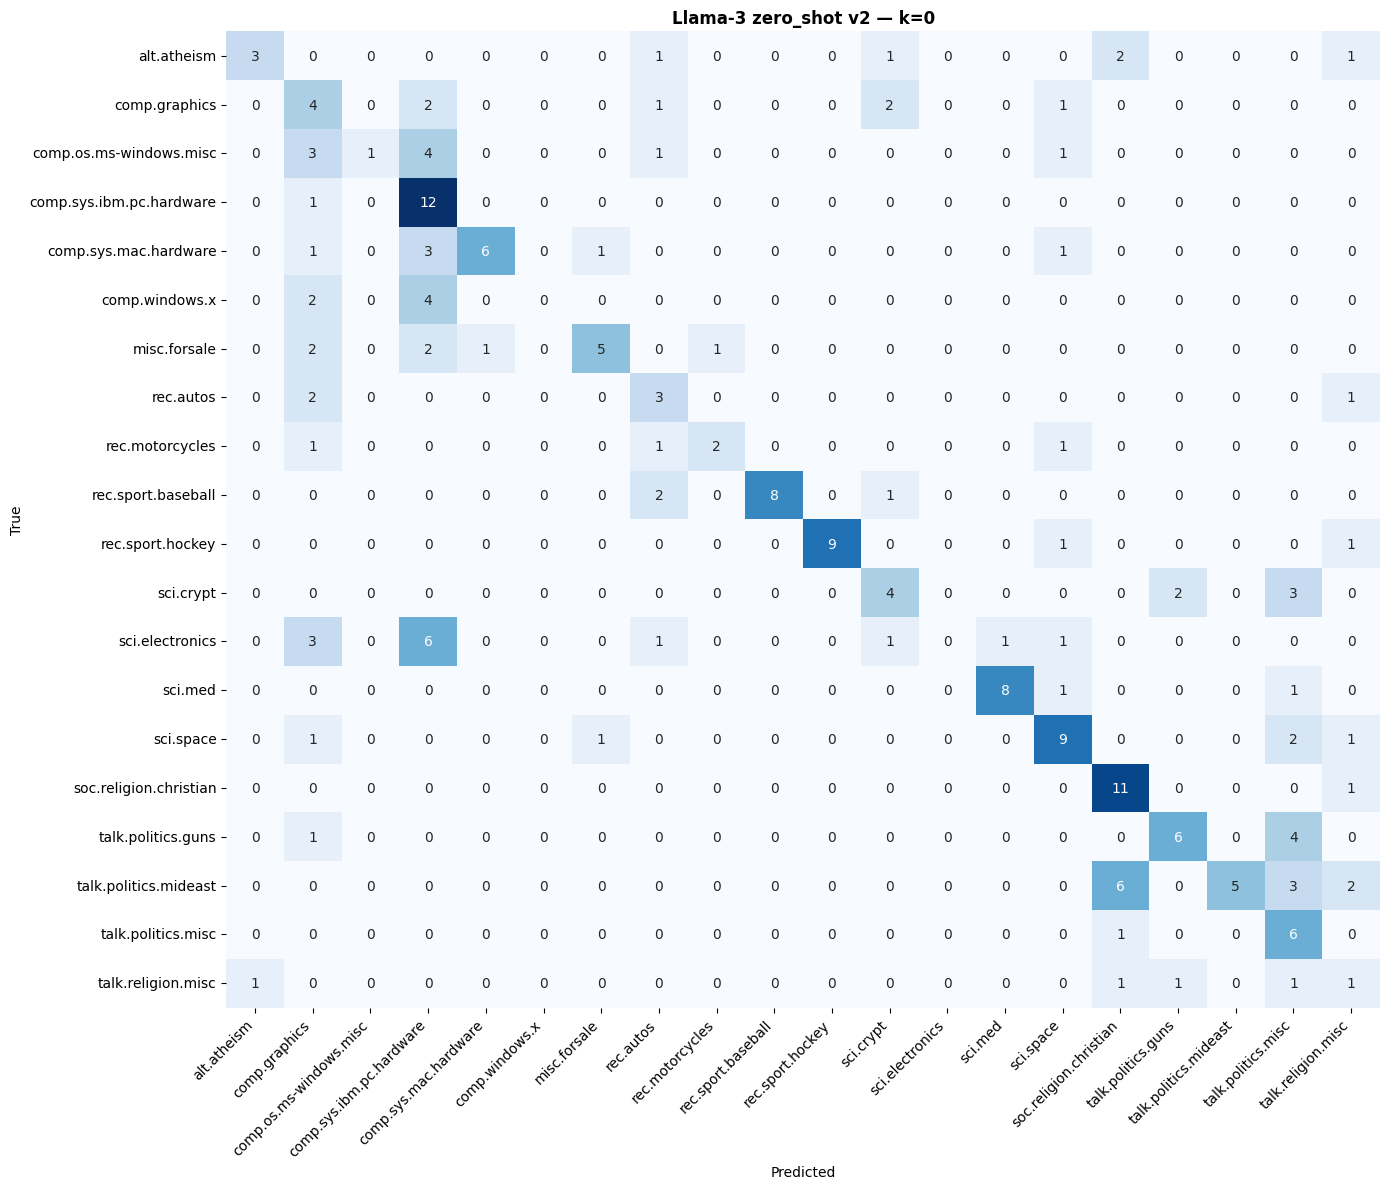

  Saved: outputs/plots/task4_zero_shot_cm_v2.png


Llama few_shot: 100%|██████████| 200/200 [04:15<00:00,  1.28s/it]



[few_shot]
  Accuracy: 0.4750
  F1:       0.4200
  Unparseable: 2/200 (1.0%)
                          precision    recall  f1-score   support

             alt.atheism       1.00      0.25      0.40         8
           comp.graphics       0.38      0.50      0.43        10
 comp.os.ms-windows.misc       0.00      0.00      0.00        10
comp.sys.ibm.pc.hardware       0.36      0.92      0.52        13
   comp.sys.mac.hardware       0.71      0.45      0.56        11
          comp.windows.x       0.00      0.00      0.00         5
            misc.forsale       0.50      0.64      0.56        11
               rec.autos       0.40      0.33      0.36         6
         rec.motorcycles       0.50      0.20      0.29         5
      rec.sport.baseball       1.00      0.64      0.78        11
        rec.sport.hockey       1.00      0.82      0.90        11
               sci.crypt       0.67      0.44      0.53         9
         sci.electronics       0.43      0.23      0.30        

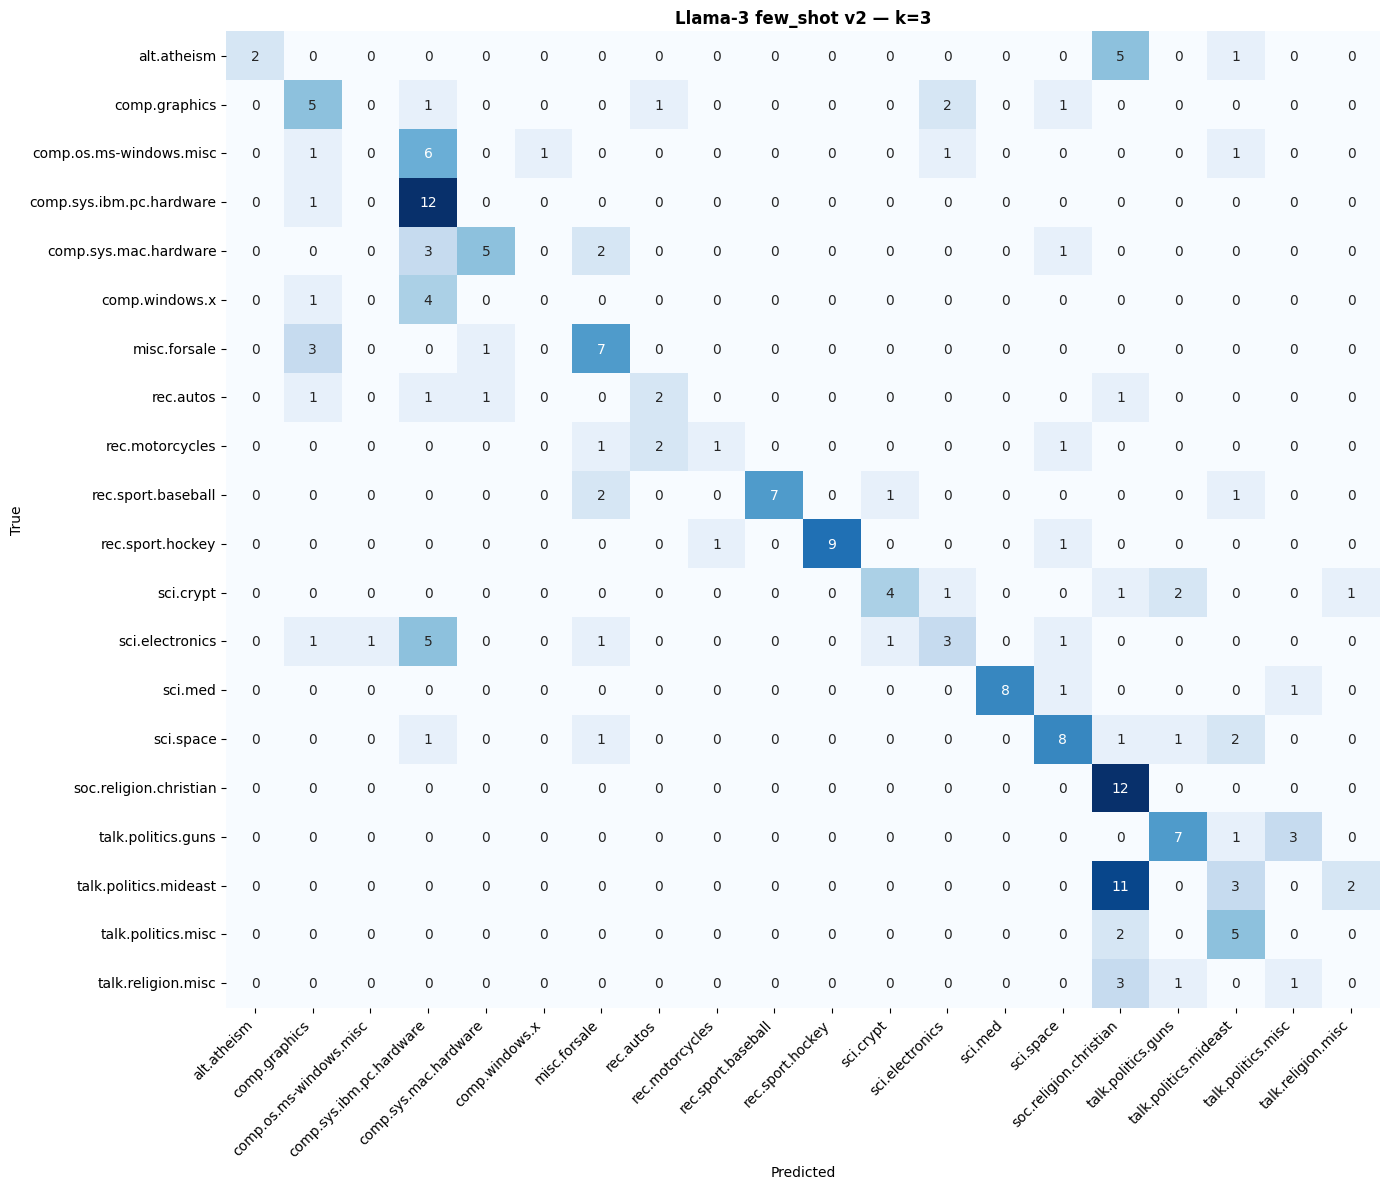

  Saved: outputs/plots/task4_few_shot_cm_v2.png


fs_accuracy_v2,▁
fs_f1_v2,▁
fs_unparseable_v2,▁
zs_accuracy_v2,▁
zs_f1_v2,▁
zs_unparseable_v2,▁
fs_accuracy_v2,0.475
fs_f1_v2,0.42
fs_unparseable_v2,2
zs_accuracy_v2,0.515
zs_f1_v2,0.47468



TASK 4 v2 — Summary
Zero-shot v2: acc=0.5150  F1=0.4747  unparseable=0/200
Few-shot v2:  acc=0.4750  F1=0.4200  unparseable=2/200


In [19]:
# TASK 4 v2 — FIXED chat-template call
import json
import random
import torch
from collections import Counter
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import numpy as np

import config

CATEGORIES = [
    'alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc',
    'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware',
    'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles',
    'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt',
    'sci.electronics', 'sci.med', 'sci.space',
    'soc.religion.christian', 'talk.politics.guns',
    'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc'
]

# ---- LOAD DATA ----
print("Loading 20 Newsgroups...")
train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test  = fetch_20newsgroups(subset='test',  remove=('headers', 'footers', 'quotes'))

rng = random.Random(config.RANDOM_SEED)
indices = rng.sample(range(len(test.data)), config.LLAMA_EVAL_SAMPLES)
eval_texts  = [test.data[i]  for i in indices]
eval_labels = [test.target[i] for i in indices]

# ---- MODEL ALREADY LOADED from previous cell ----
# We're reusing model and tokenizer from the previous run

SYSTEM = (
    "You are an expert text classifier for the 20 Newsgroups dataset. "
    "Given a post, output EXACTLY one category name from this list — and nothing else. "
    "Do not explain. Do not add any words. Just output the category name.\n\n"
    "Categories:\n" + "\n".join(f"- {c}" for c in CATEGORIES)
)

def build_user_message(post_text, examples=None):
    msg = ""
    if examples:
        msg += f"Here are {len(examples)} example classifications:\n\n"
        for ex_text, ex_label in examples:
            msg += f'POST: """{ex_text[:400]}"""\nCATEGORY: {ex_label}\n\n'
        msg += "---\nNow classify this post:\n\n"
    msg += f'POST: """{post_text[:1500]}"""\nCATEGORY:'
    return msg

def classify(post_text, examples=None):
    messages = [
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": build_user_message(post_text, examples)},
    ]
    # FIX: get formatted string first, then tokenize separately
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(prompt_text, return_tensors='pt', truncation=True,
                       max_length=4096).to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=20,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=[tokenizer.eos_token_id,
                          tokenizer.convert_tokens_to_ids("<|eot_id|>")],
        )
    response = tokenizer.decode(out[0, inputs['input_ids'].shape[1]:],
                                 skip_special_tokens=True).strip()
    return response

# ---- PARSING ----
def parse_to_category(text):
    text_low = text.lower().strip()

    for i, c in enumerate(CATEGORIES):
        if c.lower() == text_low or c.lower() in text_low.split('\n')[0]:
            return i

    keyword_map = {
        'atheism': 0, 'graphics': 1, 'ms-windows': 2, 'windows.misc': 2,
        'ibm.pc': 3, 'pc.hardware': 3, 'mac': 4, 'macintosh': 4,
        'windows.x': 5, 'x11': 5, 'forsale': 6, 'for sale': 6, 'sale': 6,
        'autos': 7, 'cars': 7, 'automobile': 7,
        'motorcycle': 8, 'bike': 8,
        'baseball': 9, 'hockey': 10, 'crypt': 11, 'encryption': 11,
        'electronics': 12, 'sci.med': 13, 'medicine': 13, 'medical': 13,
        'space': 14, 'nasa': 14, 'astron': 14,
        'christian': 15, 'religion.christ': 15,
        'guns': 16, 'firearm': 16, 'mideast': 17, 'middle east': 17,
        'politics.misc': 18, 'religion.misc': 19, 'religion misc': 19,
    }
    for kw, idx in keyword_map.items():
        if kw in text_low:
            return idx
    return None

def pick_diverse_examples(train_texts, train_labels, n_examples, seed=42):
    rng = random.Random(seed)
    by_cat = {}
    for t, y in zip(train_texts, train_labels):
        if 100 < len(t) < 1500:
            by_cat.setdefault(y, []).append(t)
    chosen_cats = rng.sample(list(by_cat.keys()), n_examples)
    return [(rng.choice(by_cat[c]), CATEGORIES[c]) for c in chosen_cats]

def evaluate(examples, name):
    preds = []
    unparseable = 0
    for txt in tqdm(eval_texts, desc=f'Llama {name}'):
        resp = classify(txt, examples=examples)
        cat = parse_to_category(resp)
        if cat is None:
            unparseable += 1
            preds.append(-1)
        else:
            preds.append(cat)

    y_true = np.array(eval_labels)
    y_pred = np.array(preds)
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0,
        labels=list(range(20)),
    )
    print(f"\n[{name}]")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1:       {f1:.4f}")
    print(f"  Unparseable: {unparseable}/{len(preds)} ({unparseable/len(preds)*100:.1f}%)")

    valid = y_pred >= 0
    print(classification_report(
        y_true[valid], y_pred[valid],
        target_names=CATEGORIES, zero_division=0, digits=2,
    ))

    cm = confusion_matrix(y_true[valid], y_pred[valid], labels=list(range(20)))
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CATEGORIES, yticklabels=CATEGORIES, cbar=False)
    plt.title(f'Llama-3 {name} v2 — k={config.LLAMA_NUM_FEW_SHOT if examples else 0}',
              fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    out = f'outputs/plots/task4_{name}_cm_v2.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {out}")
    return acc, f1, unparseable

# W&B init
wandb.init(project=config.WANDB_PROJECT, name='task4_llama_v2 collab',
           config={'fix': 'chat_template + diverse_few_shot'}, reinit=True)

# Zero-shot
zs_acc, zs_f1, zs_unp = evaluate(examples=None, name='zero_shot')

# Few-shot
fs_examples = pick_diverse_examples(train.data, train.target,
                                      n_examples=config.LLAMA_NUM_FEW_SHOT)
fs_acc, fs_f1, fs_unp = evaluate(examples=fs_examples, name='few_shot')

wandb.log({
    'zs_accuracy_v2': zs_acc, 'zs_f1_v2': zs_f1, 'zs_unparseable_v2': zs_unp,
    'fs_accuracy_v2': fs_acc, 'fs_f1_v2': fs_f1, 'fs_unparseable_v2': fs_unp,
})
wandb.finish()

print("\n" + "="*60)
print("TASK 4 v2 — Summary")
print("="*60)
print(f"Zero-shot v2: acc={zs_acc:.4f}  F1={zs_f1:.4f}  unparseable={zs_unp}/200")
print(f"Few-shot v2:  acc={fs_acc:.4f}  F1={fs_f1:.4f}  unparseable={fs_unp}/200")